# Machine Learning Model Training for Stroke Warning System

## Giới thiệu

Notebook này thực hiện tiền xử lý dữ liệu, khám phá dữ liệu, huấn luyện và so sánh nhiều mô hình máy học (Random Forest, SVM, Naive Bayes, Logistic Regression) để dự đoán nguy cơ đột quỵ. Bao gồm đánh giá chi tiết (accuracy, precision, recall, F1, ROC-AUC), trực quan hóa (ROC, confusion matrix) và phân tích feature importance. Thiết kế để chạy từ thư mục `report/` hoặc project root; hàm nạp dữ liệu sẽ tự tìm `brain_stroke.csv` trong các thư mục cha nếu cần.

## 1. Import thư viện cần

In [1]:
# Ensure required plotting & ML packages are installed in this environment
%pip install matplotlib seaborn scikit-learn --quiet

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## 2. Nạp dữ liệu từ CSV

In [2]:
def load_data_from_csv():
    filename = 'brain_stroke.csv'
    cwd = os.getcwd()
    csv_path = None

    # Search current dir and up to 4 parent levels
    for _ in range(5):
        candidate = os.path.join(cwd, filename)
        if os.path.exists(candidate):
            csv_path = candidate
            break
        parent = os.path.dirname(cwd)
        if parent == cwd:
            break
        cwd = parent

    # Final fallback: project root relative to this notebook (one level up)
    if csv_path is None:
        candidate = os.path.abspath(os.path.join(os.getcwd(), '..', filename))
        if os.path.exists(candidate):
            csv_path = candidate

    if csv_path is None:
        raise FileNotFoundError(
            f"CSV '{filename}' not found. Searched current and parent directories. cwd={os.getcwd()}"
        )

    print(f"Loading CSV from: {csv_path}")
    df = pd.read_csv(csv_path)

    # Normalize column names to match expected schema
    rename_map = {
        'Residence_type': 'residence_type',
        'Avg_glucose_level': 'avg_glucose_level',
    }
    df = df.rename(columns=rename_map)

    # Ensure required columns exist
    required = {
        'age', 'gender', 'hypertension', 'heart_disease', 'ever_married',
        'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
        'smoking_status', 'stroke'
    }

    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV missing required columns: {missing}")

    return df


In [3]:
# Load data from CSV
try:
    df = load_data_from_csv()
except Exception as e:
    print(f"Failed to load data from CSV: {e}")
    df = pd.DataFrame()

# Display dataset info
if not df.empty:
    print(f"\nDataset shape: {df.shape}")
    print(f"\nClass distribution:")
    print(df['stroke'].value_counts())
    print(f"\nFirst few rows:")
    display(df.head())
else:
    print("No data available to train the model.")

Loading CSV from: c:\Users\Lenovo\Desktop\Master\Intelligence_Sys\stroke-warning-system\brain_stroke.csv

Dataset shape: (4981, 11)

Class distribution:
stroke
0    4733
1     248
Name: count, dtype: int64

First few rows:


,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


## 3. Phân tích dữ liệu

### Tổng quan

In [4]:
if not df.empty:
    print("="*60)
    print("DATASET INFORMATION")
    print("="*60)
    print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nColumn Names and Types:")
    print(df.dtypes)

    print("\n" + "="*60)
    print("MISSING VALUES")
    print("="*60)
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Percentage': missing_pct
    })
    print(missing_df[missing_df['Missing Count'] > 0])

    print("\n" + "="*60)
    print("STATISTICAL SUMMARY - NUMERICAL FEATURES")
    print("="*60)
    print(df.describe())

    print("\n" + "="*60)
    print("STATISTICAL SUMMARY - CATEGORICAL FEATURES")
    print("="*60)
    print(df.describe(include=['object']))

    print("\n" + "="*60)
    print("TARGET VARIABLE DISTRIBUTION")
    print("="*60)
    stroke_dist = df['stroke'].value_counts()
    print(stroke_dist)
    print(f"\nStroke Rate: {(stroke_dist[1] / len(df) * 100):.2f}%")
    print(f"Non-Stroke Rate: {(stroke_dist[0] / len(df) * 100):.2f}%")
    print(f"Class Imbalance Ratio: 1:{stroke_dist[0]/stroke_dist[1]:.1f}")

DATASET INFORMATION

Dataset Shape: 4981 rows × 11 columns

Column Names and Types:
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []

STATISTICAL SUMMARY - NUMERICAL FEATURES
               age  hypertension  heart_disease  avg_glucose_level  \
count  4981.000000   4981.000000    4981.000000        4981.000000   
mean     43.419859      0.096165       0.055210         105.943562   
std      22.662755      0.294848       0.228412          45.075373   
min       0.080000      0.000000       0.000000          55.120000   
25%      25.000000      0.000000       0.000000          77.230000   
50%      45.000000      0.000000       0.0

### Phân phối của nhãn

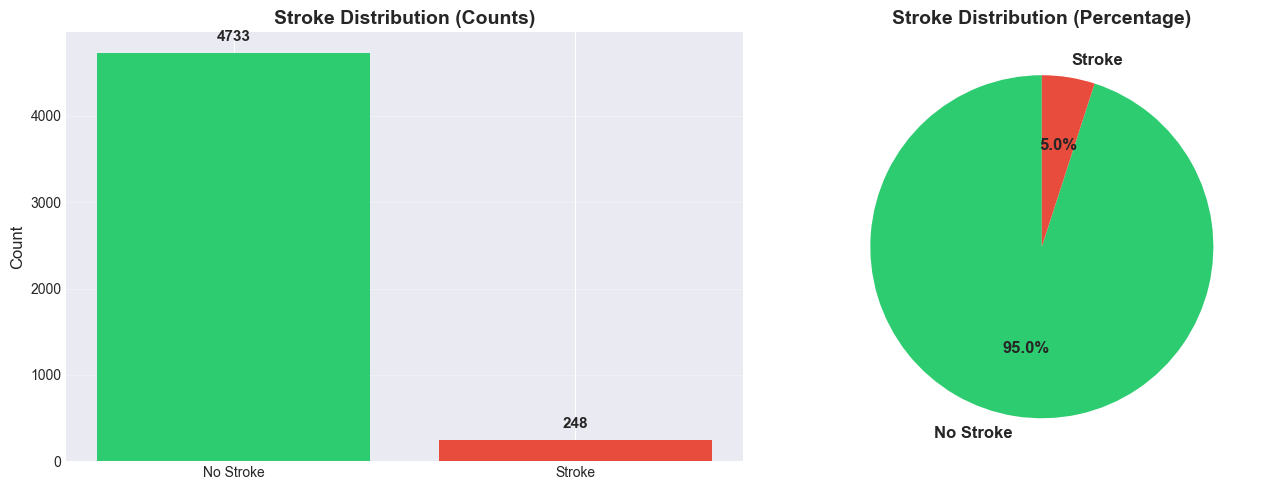

Imbalance detected - Stroke cases are only 4.98% of the data


In [5]:
if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Count plot
    stroke_counts = df['stroke'].value_counts()
    axes[0].bar(['No Stroke', 'Stroke'], stroke_counts.values, color=['#2ecc71', '#e74c3c'])
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Stroke Distribution (Counts)', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(stroke_counts.values):
        axes[0].text(i, v + 100, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Pie chart
    colors = ['#2ecc71', '#e74c3c']
    axes[1].pie(stroke_counts.values, labels=['No Stroke', 'Stroke'], autopct='%1.1f%%',
                startangle=90, colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold'})
    axes[1].set_title('Stroke Distribution (Percentage)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f"Imbalance detected - Stroke cases are only {(stroke_counts[1]/len(df)*100):.2f}% of the data")

### Phân phối của những features khác

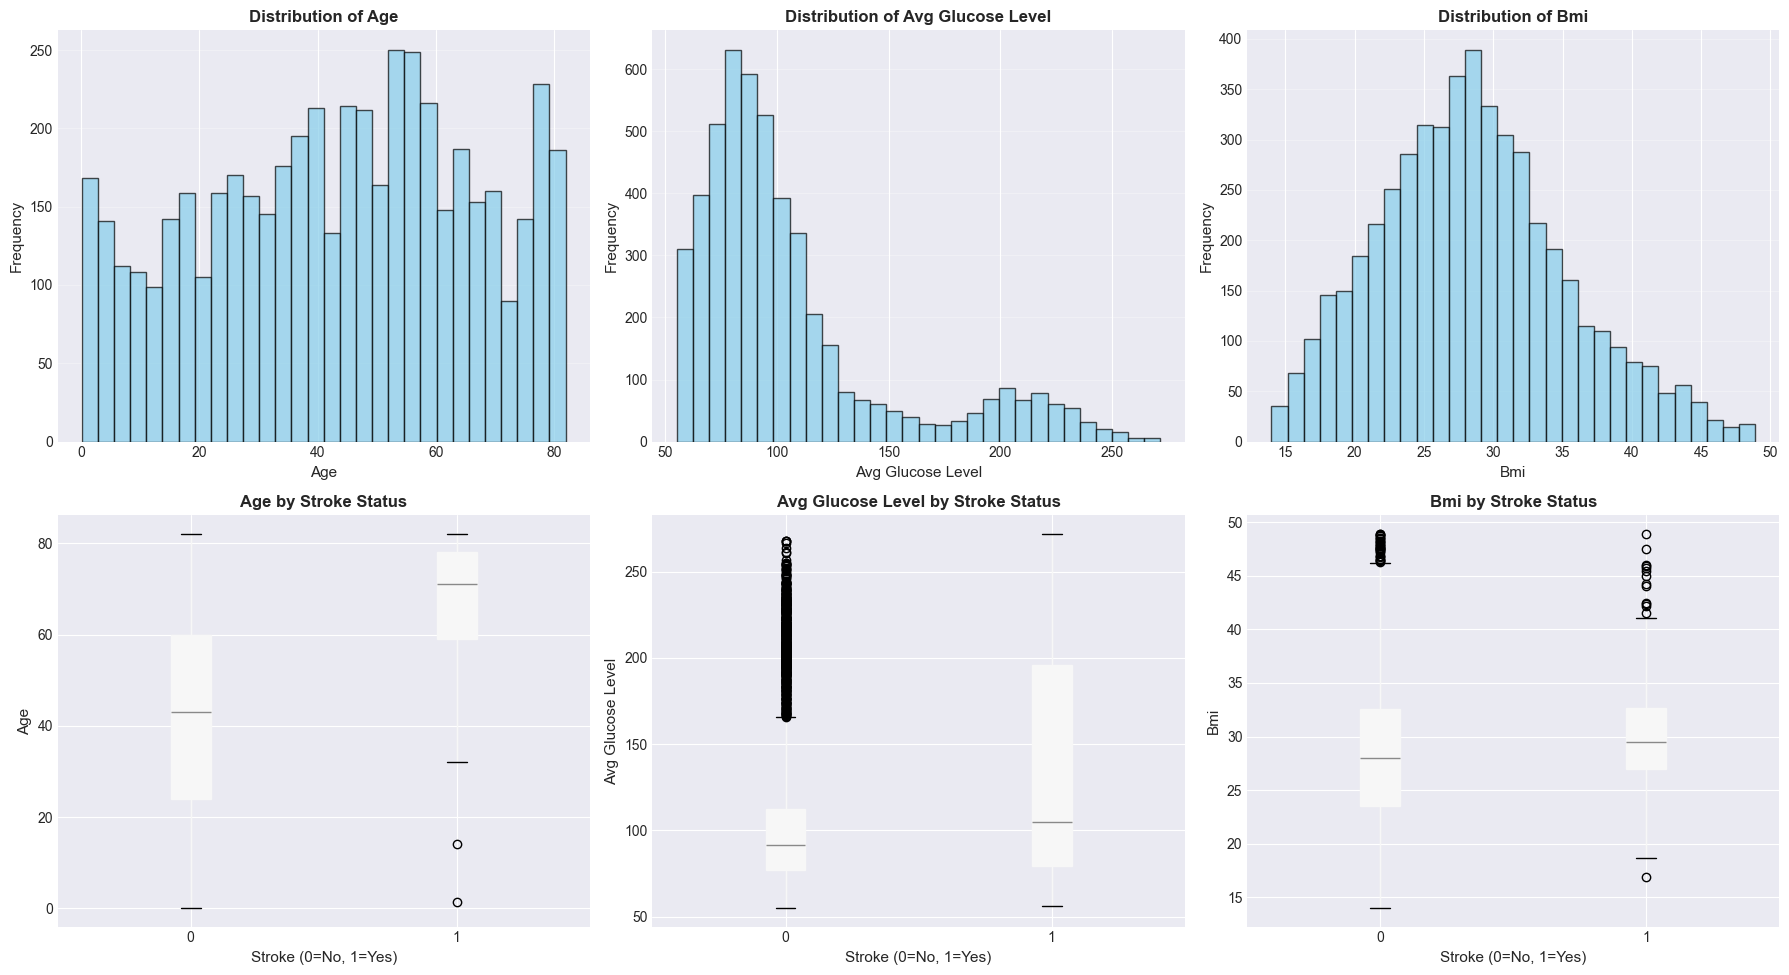

✓ Numerical features visualized


In [ ]:
if not df.empty:
    numerical_cols = ['age', 'avg_glucose_level', 'bmi']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for idx, col in enumerate(numerical_cols):
        # Histograms
        axes[0, idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[0, idx].set_xlabel(col.replace('_', ' ').title(), fontsize=11)
        axes[0, idx].set_ylabel('Frequency', fontsize=11)
        axes[0, idx].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
        axes[0, idx].grid(axis='y', alpha=0.3)

        # Box plots by stroke
        df.boxplot(column=col, by='stroke', ax=axes[1, idx], patch_artist=True)
        axes[1, idx].set_xlabel('Stroke (0=No, 1=Yes)', fontsize=11)
        axes[1, idx].set_ylabel(col.replace('_', ' ').title(), fontsize=11)
        axes[1, idx].set_title(f'{col.replace("_", " ").title()} by Stroke Status', fontsize=12, fontweight='bold')
        axes[1, idx].get_figure().suptitle('')  # Remove auto title

    plt.tight_layout()
    plt.show()

### Sự tương quan

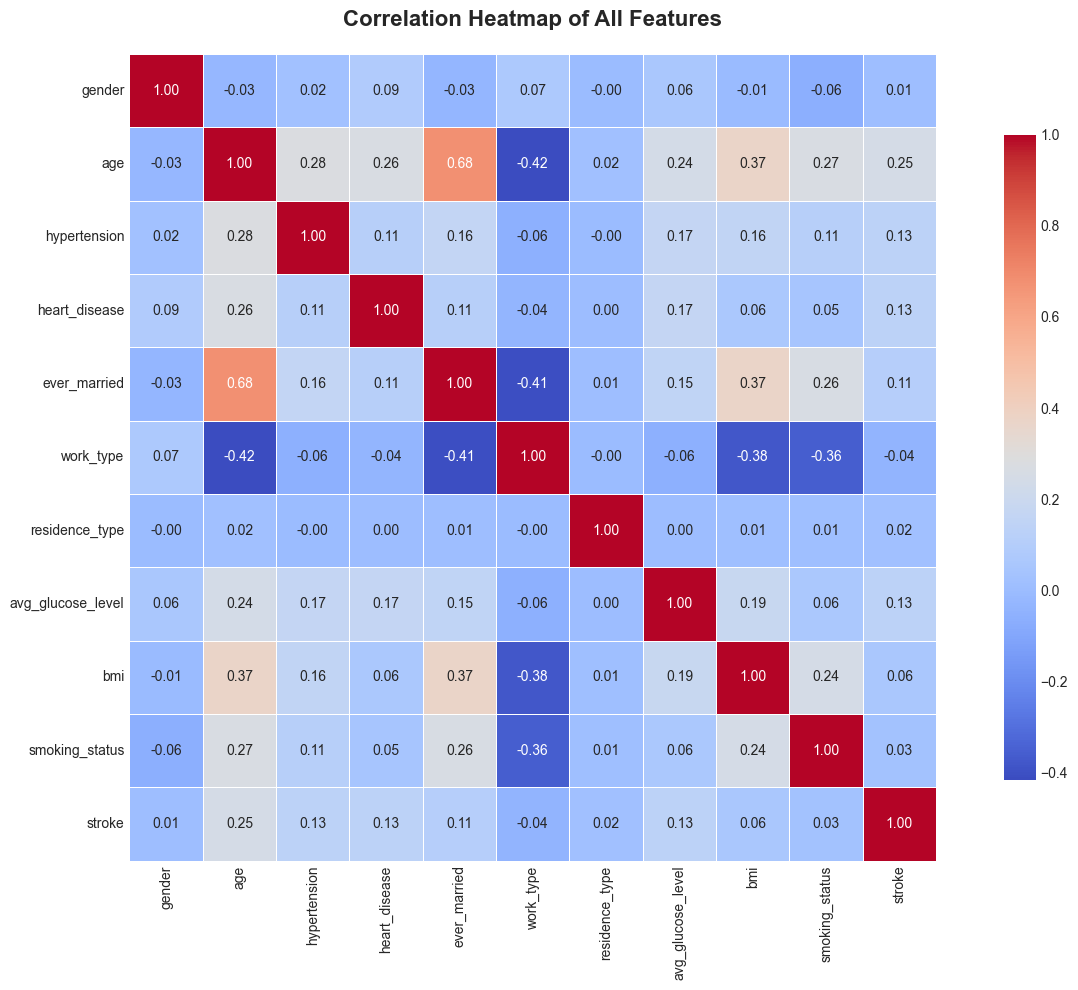


CORRELATIONS WITH STROKE (Target Variable)
stroke               1.000000
age                  0.246478
heart_disease        0.134610
avg_glucose_level    0.133227
hypertension         0.131965
ever_married         0.108398
bmi                  0.056926
smoking_status       0.027463
residence_type       0.016494
gender               0.008870
work_type           -0.041835
Name: stroke, dtype: float64

 Top positive correlations with stroke:
age                  0.246478
heart_disease        0.134610
avg_glucose_level    0.133227
Name: stroke, dtype: float64

 Top negative correlations with stroke:
work_type   -0.041835
Name: stroke, dtype: float64


In [8]:
if not df.empty:
    # Create a copy for encoding
    df_encoded = df.copy()

    # Encode categorical variables for correlation
    le = LabelEncoder()
    categorical_cols = ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']
    for col in categorical_cols:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

    # Compute correlation matrix
    correlation_matrix = df_encoded.corr()

    # Plot heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Heatmap of All Features', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    # Show correlations with stroke
    print("\n" + "="*60)
    print("CORRELATIONS WITH STROKE (Target Variable)")
    print("="*60)
    stroke_corr = correlation_matrix['stroke'].sort_values(ascending=False)
    print(stroke_corr)

    print("\n Top positive correlations with stroke:")
    print(stroke_corr[stroke_corr > 0].iloc[1:4])  # Skip stroke itself

    print("\n Top negative correlations with stroke:")
    print(stroke_corr[stroke_corr < 0].iloc[-3:])

### Phân tích feature Age - Feature chính

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30680\4293041985.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stroke_rate = df.groupby('age_group')['stroke'].mean() * 100
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30680\4293041985.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='stroke', y='age', ax=axes[2], palette=['#2ecc71', '#e74c3c'])


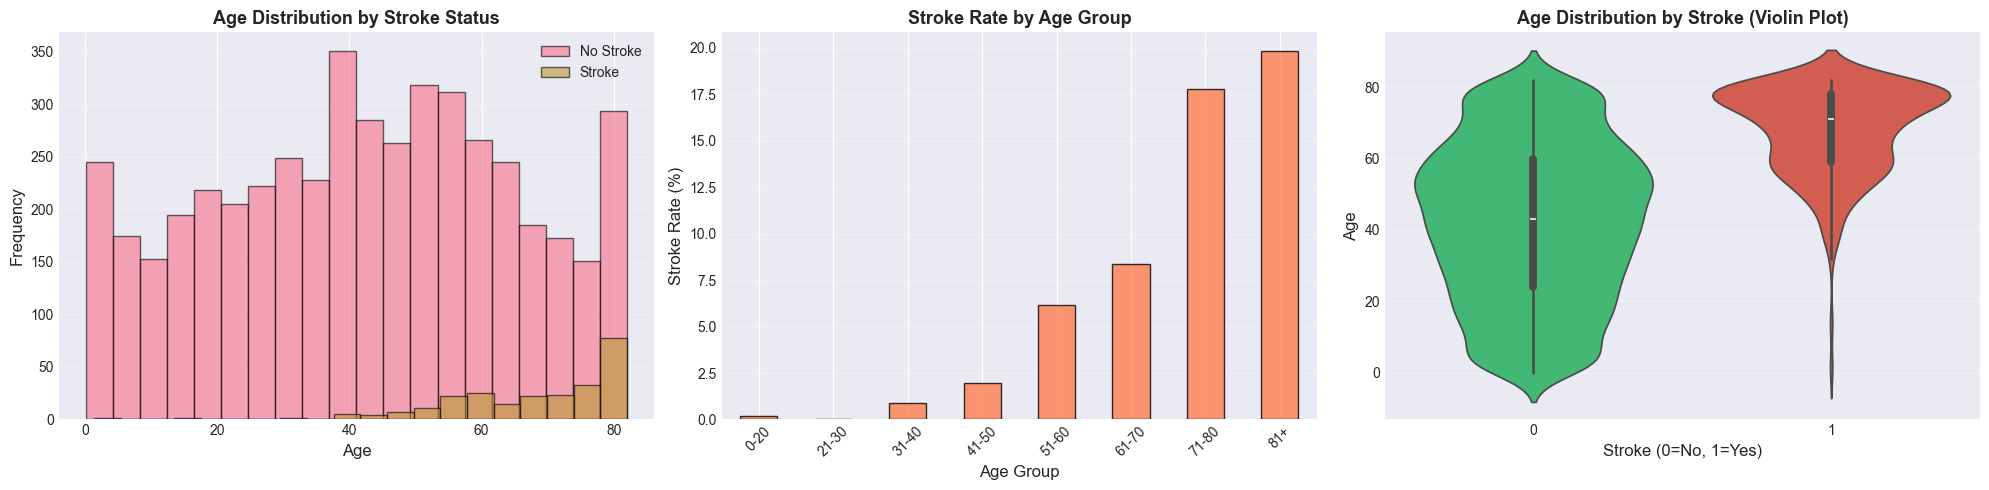


AGE STATISTICS BY STROKE STATUS
         count       mean        std   min   25%   50%   75%   max
stroke                                                            
0       4733.0  42.141348  22.345036  0.08  24.0  43.0  60.0  82.0
1        248.0  67.819839  12.670565  1.32  59.0  71.0  78.0  82.0


In [9]:
if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Age distribution by stroke
    for stroke_val in [0, 1]:
        data = df[df['stroke'] == stroke_val]['age']
        axes[0].hist(data, bins=20, alpha=0.6, label=f'Stroke={stroke_val}', edgecolor='black')
    axes[0].set_xlabel('Age', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Age Distribution by Stroke Status', fontsize=13, fontweight='bold')
    axes[0].legend(['No Stroke', 'Stroke'])
    axes[0].grid(axis='y', alpha=0.3)

    # Stroke rate by age group
    df['age_group'] = pd.cut(df['age'], bins=[0, 20, 30, 40, 50, 60, 70, 80, 100],
                              labels=['0-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81+'])
    age_stroke_rate = df.groupby('age_group')['stroke'].mean() * 100
    age_stroke_rate.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black', alpha=0.8)
    axes[1].set_xlabel('Age Group', fontsize=12)
    axes[1].set_ylabel('Stroke Rate (%)', fontsize=12)
    axes[1].set_title('Stroke Rate by Age Group', fontsize=13, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

    # Violin plot
    sns.violinplot(data=df, x='stroke', y='age', ax=axes[2], palette=['#2ecc71', '#e74c3c'])
    axes[2].set_xlabel('Stroke (0=No, 1=Yes)', fontsize=12)
    axes[2].set_ylabel('Age', fontsize=12)
    axes[2].set_title('Age Distribution by Stroke (Violin Plot)', fontsize=13, fontweight='bold')
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n" + "="*60)
    print("AGE STATISTICS BY STROKE STATUS")
    print("="*60)
    print(df.groupby('stroke')['age'].describe())

## 4. Xử lý dữ liệu

- Thêm giá trị trung bình cho các feature bị thiếu.
- Chuyển đổi các giá trị yes/no về nhị phân 0/1.
- Chuẩn hóa dữ liệu.

In [18]:
def preprocess_data(df: pd.DataFrame):
    """Preprocess and encode categorical variables"""
    df = df.copy()

    if df.empty:
        raise ValueError("No data available to train the model.")

    # Drop 'age_group' column if it exists, as it was created for EDA and is not numeric for scaling
    if 'age_group' in df.columns:
        df = df.drop('age_group', axis=1)

    # Basic NA handling for numeric columns (median fill)
    numeric_cols = ['age', 'avg_glucose_level', 'bmi']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Encode categorical columns
    le = LabelEncoder()
    categorical_columns = ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']
    for col in categorical_columns:
        if col in df.columns:
            df[col] = df[col].astype(str)
            df[col] = le.fit_transform(df[col])

    # Features/target split
    X = df.drop('stroke', axis=1)
    y = df['stroke'].astype(int)

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, scaler, list(X.columns)

In [19]:
# Preprocess the data
if not df.empty:
    X, y, scaler, feature_names = preprocess_data(df)
    print(f"Data preprocessed")
    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"\nFeature names: {feature_names}")
else:
    print(" Failed to preprocess empty dataframe")

Data preprocessed
Features shape: (4981, 10)
Target shape: (4981,)

Feature names: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']


## 5. Tách tập huấn luyện và tập kiểm thử

In [12]:
if not df.empty:
    # Stratified train/test split to maintain balance
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    for train_idx, test_idx in sss.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Validate both sets contain both classes
    assert y_train.nunique() > 1 and y_test.nunique() > 1, "Train/test must contain both classes."

    print(f"Data split completed")
    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Test set size: {X_test.shape[0]} samples")
    print(f"\nTraining set class distribution:")
    print(y_train.value_counts())
    print(f"\nTest set class distribution:")
    print(y_test.value_counts())
else:
    print("Cannot split empty dataframe")

Data split completed
Training set size: 3984 samples
Test set size: 997 samples

Training set class distribution:
stroke
0    3786
1     198
Name: count, dtype: int64

Test set class distribution:
stroke
0    947
1     50
Name: count, dtype: int64


## 6. So sánh từng model
Model trong hệ thống: Random Forest, Support Vector Machine (SVM), Naive Bayes và Logistic Regression.

Mục tiêu:
- Huấn luyện từng mô hình trên tập huấn luyện (`X_train`, `y_train`).
- Đánh giá trên tập kiểm tra (`X_test`, `y_test`) và tính các chỉ số chính: **accuracy**, **precision**, **recall**, **F1-score**, và **ROC-AUC** (nếu có thể tính được).
- Trực quan hoá kết quả bằng bảng so sánh, biểu đồ thanh cho các chỉ số, ROC curves và ma trận nhầm lẫn cho từng mô hình.

In [13]:
if not df.empty:
    print("Training multiple models: Random Forest, SVM, Naive Bayes, Logistic Regression...")

    # Define models with sensible defaults similar to app.py
    models = {
        'random_forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced'),
        'svm': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
        'naive_bayes': GaussianNB(),
        'logistic_regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    }

    trained_models = {}
    metrics_dict = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        trained_models[name] = model

        # Predictions and basic metrics
        y_pred = model.predict(X_test)
        m = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1_score': f1_score(y_test, y_pred, zero_division=0),
            'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
            'classification_report': classification_report(y_test, y_pred, zero_division=0)
        }

        # ROC-AUC using predict_proba or decision_function where available
        if hasattr(model, 'predict_proba'):
            try:
                y_proba = model.predict_proba(X_test)[:, 1]
                m['roc_auc'] = float(roc_auc_score(y_test, y_proba))
            except Exception:
                m['roc_auc'] = None
        elif hasattr(model, 'decision_function'):
            try:
                y_score = model.decision_function(X_test)
                m['roc_auc'] = float(roc_auc_score(y_test, y_score))
            except Exception:
                m['roc_auc'] = None
        else:
            m['roc_auc'] = None

        # Cross-validation (on training set) for stability
        try:
            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
            m['cv_scores'] = cv_scores.tolist()
            m['cv_mean'] = float(np.mean(cv_scores))
            m['cv_std'] = float(np.std(cv_scores))
        except Exception:
            m['cv_scores'] = []
            m['cv_mean'] = None
            m['cv_std'] = None

        # Feature importance when supported
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            fi = [{'feature': fn, 'importance': float(im)} for fn, im in zip(feature_names, importances)]
            fi.sort(key=lambda x: x['importance'], reverse=True)
            m['feature_importance'] = fi[:10]
        else:
            m['feature_importance'] = []

        metrics_dict[name] = m

    print("Training and evaluation of all models completed")
else:
    print("Cannot train on empty dataframe")

Training multiple models: Random Forest, SVM, Naive Bayes, Logistic Regression...
Training and evaluation of all models completed
Training and evaluation of all models completed


## 7. Đánh giá các mô hình

- Bảng so sánh (`accuracy`, `precision`, `recall`, `f1_score`, `roc_auc`, `cv_mean`): cho phép so sánh nhanh các mô hình về các tiêu chí chính.
- Biểu đồ ROC: thể hiện khả năng phân biệt giữa hai lớp độc lập với ngưỡng; AUC gần 1 là tốt, ~0.5 nghĩa là gần như đoán ngẫu nhiên.
- Ma trận nhầm lẫn cho từng mô hình (TN, FP, FN, TP): giúp hiểu kiểu lỗi mô hình đang mắc phải.
- Feature importances (nếu có, ví dụ Random Forest): nêu những biến đóng góp nhiều nhất.

Diễn giải
- Accuracy: tỷ lệ dự đoán đúng tổng thể; có thể gây hiểu lầm khi dữ liệu mất cân bằng (stroke hiếm hơn). Không phải chỉ số duy nhất để chọn mô hình.
- Precision: trong số các cá nhân được dự đoán là 'Stroke', có bao nhiêu là đúng. Quan trọng khi chi phí báo động giả cao.
- Recall (sensitivity): trong số các cá nhân thật sự bị stroke, mô hình bắt được bao nhiêu. Với bài toán y tế như phát hiện đột quỵ, **recall cao** thường được ưu tiên hơn vì False Negative (bỏ sót ca thật) có hậu quả nặng.
- F1-score: là trung bình điều hòa của precision và recall — hữu dụng khi cần cân bằng hai chỉ số.
- ROC-AUC: cho biết khả năng phân biệt lớp; so sánh mô hình bằng AUC hữu ích khi bạn muốn độ phân biệt tổng quát.
- Cross-Validation (CV mean ± std): CV mean cho ước lượng hiệu năng trung bình, CV std cho biết độ ổn định giữa các fold; std lớn → hiệu năng không ổn định.

Kết luận
- Chọn mô hình có recall cao và AUC tốt nếu mục tiêu bắt đúng các ca stroke.
- Nếu hai mô hình tương đương về recall, chọn mô hình ổn định hơn theo CV (CV mean cao, CV std thấp).
- Sau khi chọn mô hình, hiệu chỉnh ngưỡng quyết định, xác thực trên dữ liệu mới, và đánh giá chi phí/ lợi ích của false positives vs false negatives.


In [14]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
        'classification_report': classification_report(y_test, y_pred, zero_division=0)
    }

    if hasattr(model, 'predict_proba'):
        classes = getattr(model, 'classes_', None)
        if classes is not None and len(classes) > 1:
            # pick probability of class 1 if present, else map accordingly
            idx = int(np.where(classes == 1)[0][0]) if 1 in classes else 1
            y_proba = model.predict_proba(X_test)[:, idx]
            try:
                metrics['roc_auc'] = roc_auc_score(y_test, y_proba)
            except ValueError:
                metrics['roc_auc'] = None
        else:
            metrics['roc_auc'] = None
    else:
        metrics['roc_auc'] = None

    return metrics

Building comparison table and visualizations for all trained models...


,accuracy,precision,recall,f1_score,roc_auc,cv_mean
model,,,,,,
logistic_regression,0.744233,0.142857,0.82,0.243323,0.843801,0.739961
naive_bayes,0.860582,0.138211,0.34,0.196532,0.801394,0.857176
random_forest,0.947844,0.000000,0.00,0.000000,0.815903,0.949548
svm,0.761284,0.129921,0.66,0.217105,0.782429,0.765314


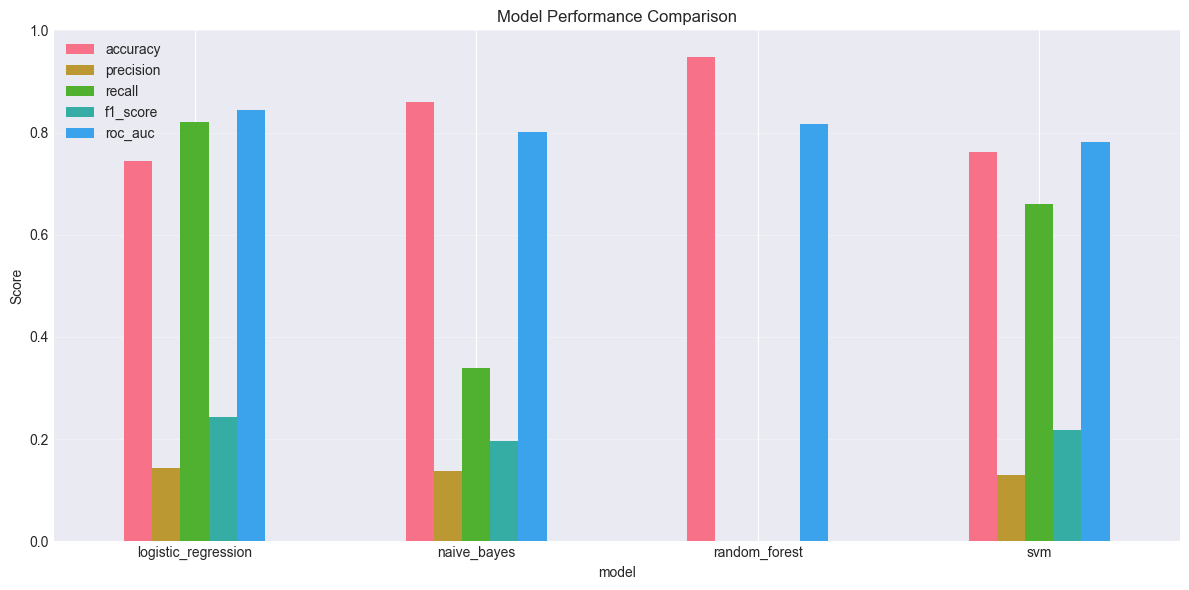

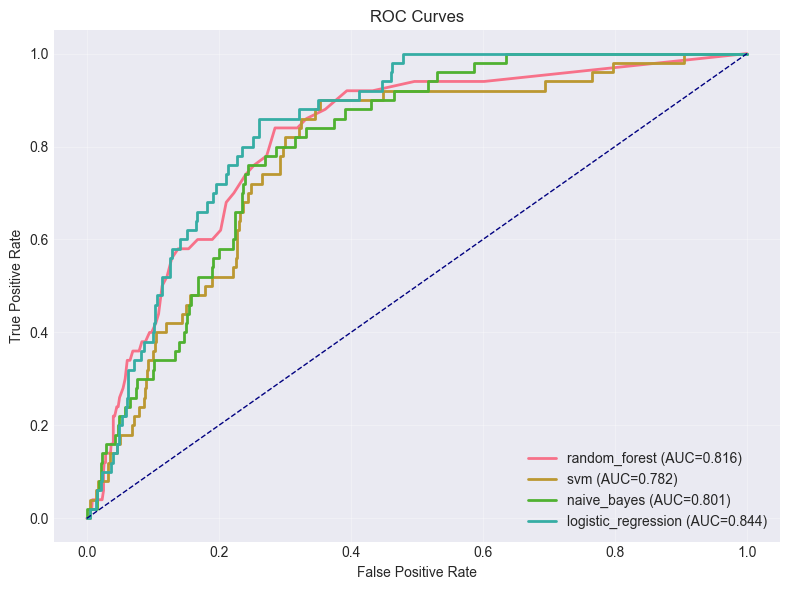

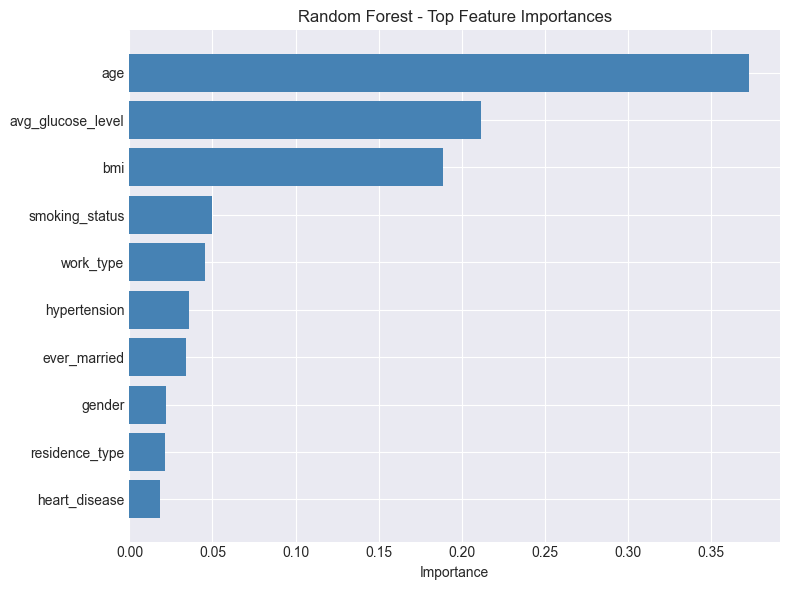

In [15]:
# Clean, working implementation for model comparison and visualizations

import math

if df.empty or 'metrics_dict' not in globals() or not metrics_dict:
    print("No trained models found or dataset empty - nothing to display.")
else:
    print("Building comparison table and visualizations for all trained models...")

    # Build comparison dataframe
    rows = []
    for name, m in metrics_dict.items():
        rows.append({
            'model': name,
            'accuracy': float(m.get('accuracy')) if m.get('accuracy') is not None else np.nan,
            'precision': float(m.get('precision')) if m.get('precision') is not None else np.nan,
            'recall': float(m.get('recall')) if m.get('recall') is not None else np.nan,
            'f1_score': float(m.get('f1_score')) if m.get('f1_score') is not None else np.nan,
            'roc_auc': float(m.get('roc_auc')) if m.get('roc_auc') is not None else np.nan,
            'cv_mean': float(m.get('cv_mean')) if m.get('cv_mean') is not None else np.nan,
        })

    comp_df = pd.DataFrame(rows).set_index('model').sort_index()
    display(comp_df)

    # Bar chart for primary metrics
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
    fig, ax = plt.subplots(figsize=(12, 6))
    comp_df[metrics_to_plot].fillna(0).plot(kind='bar', ax=ax, rot=0)
    ax.set_ylim(0, 1)
    ax.set_title('Model Performance Comparison')
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ROC Curves
    fig, ax = plt.subplots(figsize=(8, 6))
    plotted = False
    for name, model in trained_models.items() if 'trained_models' in globals() else metrics_dict.items():
        try:
            # prefer predict_proba, otherwise decision_function
            if hasattr(model, 'predict_proba'):
                # find index of positive class if classes_ exists
                if hasattr(model, 'classes_') and 1 in model.classes_:
                    idx = int(np.where(model.classes_ == 1)[0][0])
                    y_score = model.predict_proba(X_test)[:, idx]
                else:
                    y_score = model.predict_proba(X_test)[:, 1]
            elif hasattr(model, 'decision_function'):
                y_score = model.decision_function(X_test)
            else:
                # cannot plot ROC for this model
                continue

            fpr, tpr, _ = roc_curve(y_test, y_score)
            auc = roc_auc_score(y_test, y_score)
            ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
            plotted = True
        except Exception as e:
            # skip model if ROC cannot be computed
            print(f"Could not compute ROC for {name}: {e}")
            continue

    if plotted:
        ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title('ROC Curves')
        ax.legend(loc='lower right')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No ROC curves could be plotted (no model provides scores/probabilities).")

    # Show Random Forest feature importance if available
    if 'random_forest' in trained_models and hasattr(trained_models['random_forest'], 'feature_importances_'):
        rf = trained_models['random_forest']
        fi = rf.feature_importances_
        rf_fi = pd.DataFrame({'feature': feature_names, 'importance': fi})
        rf_fi = rf_fi.sort_values('importance', ascending=True).tail(20)  # top 20
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.barh(rf_fi['feature'], rf_fi['importance'], color='steelblue')
        ax.set_title('Random Forest - Top Feature Importances')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.show()
    else:
        print("Random Forest feature importances not available.")